# INSTALLING LIBRARIES

In [1]:
import pandas as pd

In [2]:
trxn = pd.read_csv('Retail_data_Transactions.csv')
trxn

,customer_id,trans_date,tran_amount
0,CS5295,11-Feb-13,35
1,CS4768,15-Mar-15,39
2,CS2122,26-Feb-13,52
3,CS1217,16-Nov-11,99
4,CS1850,20-Nov-13,78
...,...,...,...
124995,CS8433,26-Jun-11,64
124996,CS7232,19-Aug-14,38
124997,CS8731,28-Nov-14,42
124998,CS8133,14-Dec-13,13


In [4]:
response = pd.read_csv('Retail_data_Response.csv')
response

,customer_id,response
0,CS1112,0
1,CS1113,0
2,CS1114,1
3,CS1115,1
4,CS1116,1
...,...,...
6879,CS8996,0
6880,CS8997,0
6881,CS8998,0
6882,CS8999,0


In [5]:
df = trxn.merge(response, on='customer_id', how='left')
df

,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0
...,...,...,...,...
124995,CS8433,26-Jun-11,64,0.0
124996,CS7232,19-Aug-14,38,0.0
124997,CS8731,28-Nov-14,42,0.0
124998,CS8133,14-Dec-13,13,0.0


# FEATURES

In [6]:
df.dtypes

customer_id     object
trans_date      object
tran_amount      int64
response       float64
dtype: object

In [7]:
df.shape

(125000, 4)

In [8]:
df.head(5)

,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0


In [9]:
df.tail(5)

,customer_id,trans_date,tran_amount,response
124995,CS8433,26-Jun-11,64,0.0
124996,CS7232,19-Aug-14,38,0.0
124997,CS8731,28-Nov-14,42,0.0
124998,CS8133,14-Dec-13,13,0.0
124999,CS7996,13-Dec-14,36,0.0


In [10]:
df.describe()

,tran_amount,response
count,125000.000000,124969.000000
mean,64.991912,0.110763
std,22.860006,0.313840
min,10.000000,0.000000
25%,47.000000,0.000000
50%,65.000000,0.000000
75%,83.000000,0.000000
max,105.000000,1.000000


# MISSING VALUES

In [11]:
df.isnull().sum()

customer_id     0
trans_date      0
tran_amount     0
response       31
dtype: int64

In [13]:
df=df.dropna()
df

,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0
...,...,...,...,...
124995,CS8433,26-Jun-11,64,0.0
124996,CS7232,19-Aug-14,38,0.0
124997,CS8731,28-Nov-14,42,0.0
124998,CS8133,14-Dec-13,13,0.0


# CHANGE DTYPES

In [15]:
df['trans_date'] = pd.to_datetime(df['trans_date'])
df['response'] = df['response'].astype('int64')
df

,customer_id,trans_date,tran_amount,response
0,CS5295,2013-02-11,35,1
1,CS4768,2015-03-15,39,1
2,CS2122,2013-02-26,52,0
3,CS1217,2011-11-16,99,0
4,CS1850,2013-11-20,78,0
...,...,...,...,...
124995,CS8433,2011-06-26,64,0
124996,CS7232,2014-08-19,38,0
124997,CS8731,2014-11-28,42,0
124998,CS8133,2013-12-14,13,0


In [18]:
set(df['response'])

{0, 1}

In [16]:
df.dtypes

customer_id            object
trans_date     datetime64[ns]
tran_amount             int64
response                int64
dtype: object

# CHECK FOR OUTLIERS 
# Z-SCORE TEST

In [29]:
from scipy import stats
import numpy as np

#calc z-score
z_scores = np.abs(stats.zscore(df['response']))

#set a thresholds
threshold = 3
outliers = z_scores>threshold

print(df['response'][outliers])

Series([], Name: response, dtype: int64)


In [33]:
from scipy import stats
import numpy as np

#calc z-score
z_scores = np.abs(stats.zscore(df['tran_amount']))

#set a thresholds
threshold = 3
outliers = z_scores>threshold

print(df['response'][outliers])

Series([], Name: response, dtype: int64)


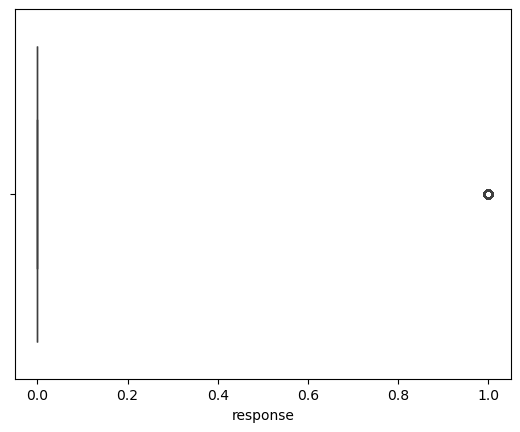

In [35]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.boxplot(x=df['response'])
plt.show()

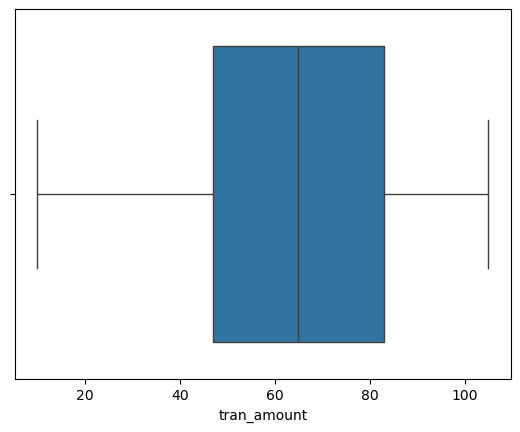

In [36]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.boxplot(x=df['tran_amount'])
plt.show()

# CREATING NEW COLUMNS

In [39]:
df['month'] = df['trans_date'].dt.month       # from trans_date column
df

,customer_id,trans_date,tran_amount,response,month
0,CS5295,2013-02-11,35,1,2
1,CS4768,2015-03-15,39,1,3
2,CS2122,2013-02-26,52,0,2
3,CS1217,2011-11-16,99,0,11
4,CS1850,2013-11-20,78,0,11
...,...,...,...,...,...
124995,CS8433,2011-06-26,64,0,6
124996,CS7232,2014-08-19,38,0,8
124997,CS8731,2014-11-28,42,0,11
124998,CS8133,2013-12-14,13,0,12


# SOME QUEST

In [41]:
monthly_sales=df.groupby('month')['tran_amount'].sum()
monthly_sales=monthly_sales.sort_values(ascending=False).reset_index().head(3)
monthly_sales

,month,tran_amount
0,8,726775
1,10,725058
2,1,724089


In [46]:
# Customers having highest number of orders #5

customer_counts = df['customer_id'].value_counts().reset_index()
customer_counts

# Sort
Top_5_cust=customer_counts.sort_values(by='count',ascending=False).head(5)
Top_5_cust

,customer_id,count
0,CS4424,39
1,CS4320,38
2,CS3799,36
3,CS3013,35
4,CS1215,35


<Axes: xlabel='customer_id', ylabel='count'>

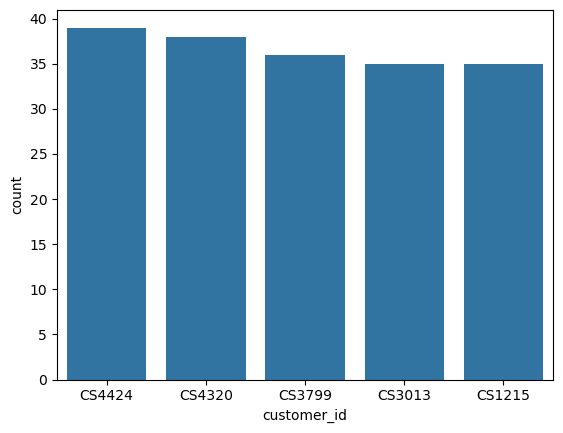

In [51]:
sns.barplot(x='customer_id',y='count',
data=Top_5_cust)

In [53]:
# Customers having highest values of orders #5

customer_sales = df.groupby('customer_id')['tran_amount'].sum().reset_index()
customer_sales

# Sort
top_5_sal = customer_sales.sort_values(by='tran_amount',ascending=False).head(5)
top_5_sal

,customer_id,tran_amount
3312,CS4424,2933
3208,CS4320,2647
4640,CS5752,2612
3548,CS4660,2527
2687,CS3799,2513


<Axes: xlabel='customer_id', ylabel='tran_amount'>

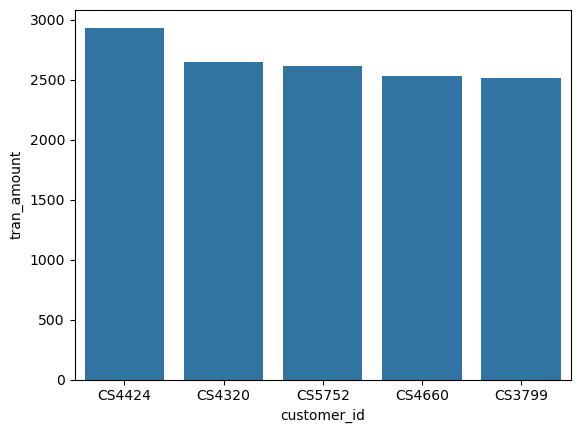

In [54]:
sns.barplot(x='customer_id',y='tran_amount',
data=top_5_sal)